In [1]:
# Copyright (c) Meta Platforms, Inc. and affiliates.

# SAM 3 Agent

This notebook shows an example of how an MLLM can use SAM 3 as a tool, i.e., "SAM 3 Agent", to segment more complex text queries such as "the leftmost child wearing blue vest".

## Env Setup

First install `sam3` in your environment using the [installation instructions](https://github.com/facebookresearch/sam3?tab=readme-ov-file#installation) in the repository.

In [2]:
import torch
# turn on tfloat32 for Ampere GPUs
# https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

# use bfloat16 for the entire notebook. If your card doesn't support it, try float16 instead
torch.autocast("cuda", dtype=torch.bfloat16).__enter__()

# inference mode for the whole notebook. Disable if you need gradients
torch.inference_mode().__enter__()

In [3]:
import os

SAM3_ROOT = "/opt/software/Grounded-SAM3-Instruct-WebTrack/.sam3_src"
os.chdir(SAM3_ROOT)

# setup GPU to use -  A single GPU is good with the purpose of this demo
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
_ = os.system("nvidia-smi")

Fri Mar 13 18:20:11 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 565.57.01              Driver Version: 565.57.01      CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100 80GB PCIe          On  |   00000000:4B:00.0 Off |                    0 |
| N/A   57C    P0             85W /  300W |   69067MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## Build SAM3 Model

In [4]:
import sam3
from sam3 import build_sam3_image_model
from sam3.model.sam3_image_processor import Sam3Processor

sam3_root = os.path.dirname(sam3.__file__)
bpe_path = f"{sam3_root}/assets/bpe_simple_vocab_16e6.txt.gz"
model = build_sam3_image_model(bpe_path=bpe_path)
processor = Sam3Processor(model, confidence_threshold=0.5)

/home/adam/miniconda3/envs/sampose/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## LLM Setup

Config which MLLM to use, it can either be a model served by vLLM that you launch from your own machine or a model is served via external API. If you want to using a vLLM model, we also provided insturctions below.

In [5]:
LLM_CONFIGS = {
    # vLLM-served models
    "qwen3_vl_2b_thinking_fp8": {
        "provider": "vllm",
        "model": "Qwen/Qwen3-VL-2B-Thinking-FP8",
    },
    # models served via external APIs
    # add your own
}

model = "qwen3_vl_2b_thinking_fp8"
LLM_API_KEY = "DUMMY_API_KEY"

llm_config = LLM_CONFIGS[model]
llm_config["api_key"] = LLM_API_KEY
llm_config["name"] = model

# setup API endpoint
if llm_config["provider"] == "vllm":
    LLM_SERVER_URL = "http://0.0.0.0:8001/v1"  # replace this with your vLLM server address as needed
else:
    LLM_SERVER_URL = llm_config["base_url"]

### Setup vLLM server 
This step is only required if you are using a model served by vLLM, skip this step if you are calling LLM using an API like Gemini and GPT.

* Install vLLM (in a separate conda env from SAM 3 to avoid dependency conflicts).
  ```bash
    conda create -n vllm python=3.12
    pip install vllm --extra-index-url https://download.pytorch.org/whl/cu128
  ```
* Start vLLM server on the same machine of this notebook
  ```bash
    # qwen 3 VL 8B thinking
    vllm serve Qwen/Qwen3-VL-8B-Thinking --tensor-parallel-size 4 --allowed-local-media-path / --enforce-eager --port 8001
  ```

## Run SAM3 Agent Inference

In [6]:
from functools import partial
from IPython.display import display, Image
from sam3.agent.client_llm import send_generate_request as send_generate_request_orig
from sam3.agent.client_sam3 import call_sam_service as call_sam_service_orig
from sam3.agent.inference import run_single_image_inference

/opt/software/Grounded-SAM3-Instruct-WebTrack/.sam3_src/sam3/agent/agent_core.py:205: SyntaxWarning: assertion is always true, perhaps remove parentheses?
  assert (


------------------------------ Starting SAM 3 Agent Session... ------------------------------ 
> Text prompt: the mouse with the large light/white patch on its back
> Image path: /home/adam/.sam3_zero_projects/553344c8-social-full-video/videos/05cfafae/frames/000789.jpg



------------------------------ Round 1------------------------------



image_path /home/adam/.sam3_zero_projects/553344c8-social-full-video/videos/05cfafae/frames/000789.jpg
🔍 Calling model Qwen/Qwen3-VL-2B-Thinking-FP8...

>>> MLLM Response [start]
Okay, let's tackle this problem. The user provided an image with two mice on a grayish surface, and the query is "the mouse with the large light/white patch on its back". First, I need to analyze the image to see which mouse has that patch.

Looking at the image, there are two mice. One mouse has a prominent white patch on its back. The other mouse doesn't have such a patch. The query specifies "the mouse with the large light/white patch", so I need to identify which mou

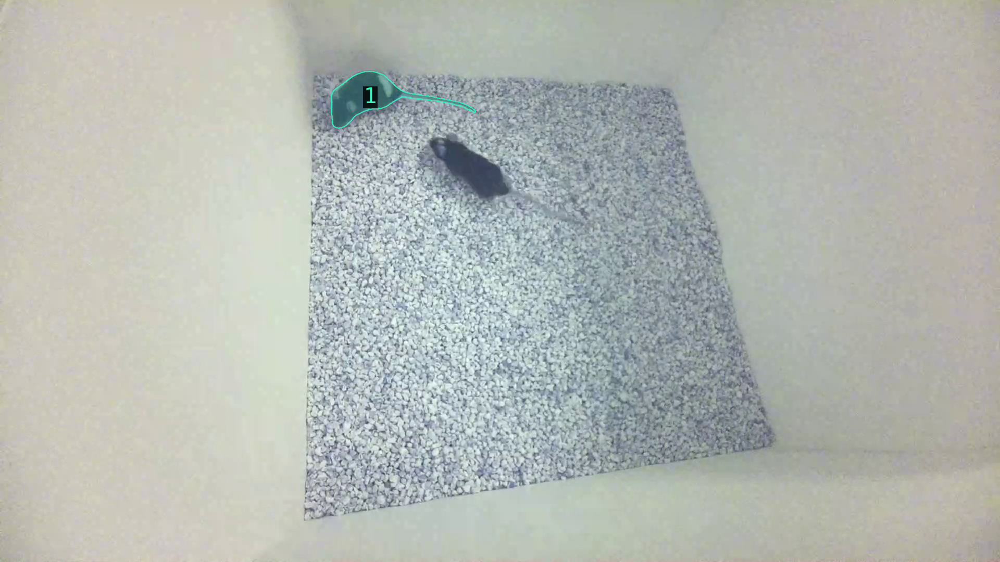

In [7]:
# prepare input args and run single image inference
image = "/home/adam/.sam3_zero_projects/553344c8-social-full-video/videos/05cfafae/frames/000789.jpg"
prompt = "the mouse with the large light/white patch on its back"
image = os.path.abspath(image)
send_generate_request = partial(send_generate_request_orig, server_url=LLM_SERVER_URL, model=llm_config["model"], api_key=llm_config["api_key"])
call_sam_service = partial(call_sam_service_orig, sam3_processor=processor)
output_image_path = run_single_image_inference(
    image, prompt, llm_config, send_generate_request, call_sam_service,
    debug=True, output_dir="agent_output"
)

# display output
if output_image_path is not None:
    display(Image(filename=output_image_path))

------------------------------ Starting SAM 3 Agent Session... ------------------------------ 
> Text prompt: the mouse with a dark back
> Image path: /home/adam/.sam3_zero_projects/553344c8-social-full-video/videos/05cfafae/frames/000789.jpg



------------------------------ Round 1------------------------------



image_path /home/adam/.sam3_zero_projects/553344c8-social-full-video/videos/05cfafae/frames/000789.jpg
🔍 Calling model Qwen/Qwen3-VL-2B-Thinking-FP8...

>>> MLLM Response [start]
Okay, let me try to figure this out. The user provided an image with two mice on a bed of small white grains, and the query is "the mouse with a dark back". First, I need to understand what the query is asking for.

The user wants to identify the mouse that has a dark back. So, looking at the image, there are two mice. Let's check their colors. The one on the left has a black and white color scheme, maybe a dark back? Wait, the mouse on the left has a black body with some white parts, but the right

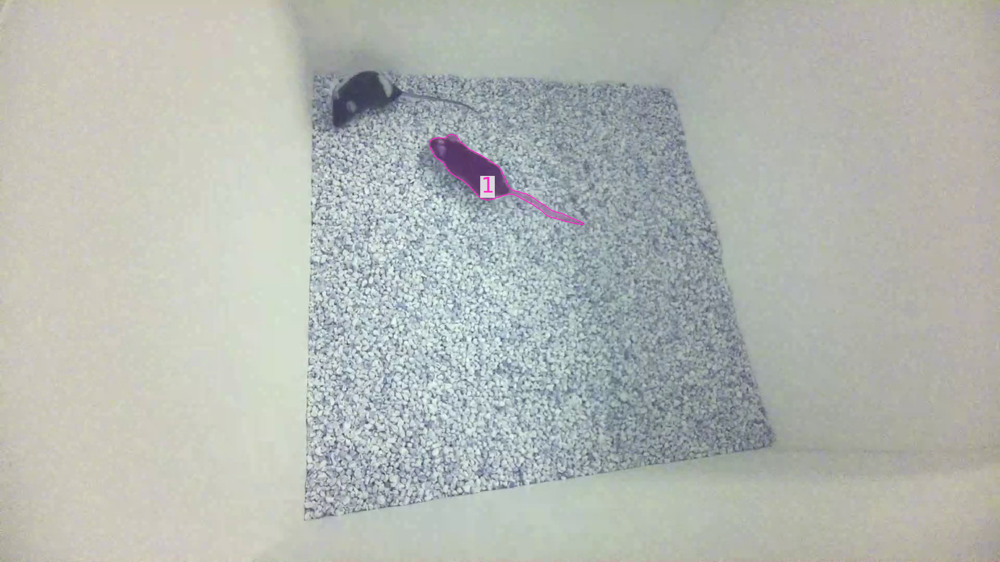

In [9]:
# prepare input args and run single image inference
image = "/home/adam/.sam3_zero_projects/553344c8-social-full-video/videos/05cfafae/frames/000789.jpg"
prompt = "the mouse with a dark back"
image = os.path.abspath(image)
send_generate_request = partial(send_generate_request_orig, server_url=LLM_SERVER_URL, model=llm_config["model"], api_key=llm_config["api_key"])
call_sam_service = partial(call_sam_service_orig, sam3_processor=processor)
output_image_path = run_single_image_inference(
    image, prompt, llm_config, send_generate_request, call_sam_service,
    debug=True, output_dir="agent_output"
)

# display output
if output_image_path is not None:
    display(Image(filename=output_image_path))

------------------------------ Starting SAM 3 Agent Session... ------------------------------ 
> Text prompt: the two mice with dark or shaved backs
> Image path: /home/adam/.sam3_zero_projects/553344c8-social-full-video/videos/05cfafae/frames/000789.jpg



------------------------------ Round 1------------------------------



image_path /home/adam/.sam3_zero_projects/553344c8-social-full-video/videos/05cfafae/frames/000789.jpg
🔍 Calling model Qwen/Qwen3-VL-2B-Thinking-FP8...

>>> MLLM Response [start]
Okay, let's tackle this. The user is asking to ground the initial user input query: "the two mice with dark or shaved backs". First, I need to look at the image provided.

The image shows two mice on a surface covered with small gravel or pebbles. The mice are dark-colored, maybe black or dark gray. The user mentioned "dark or shaved backs", so I need to check if the mice's backs are dark or shaved.

Wait, the image shows two mice. Each mouse has a dark color, but the back part—do they 

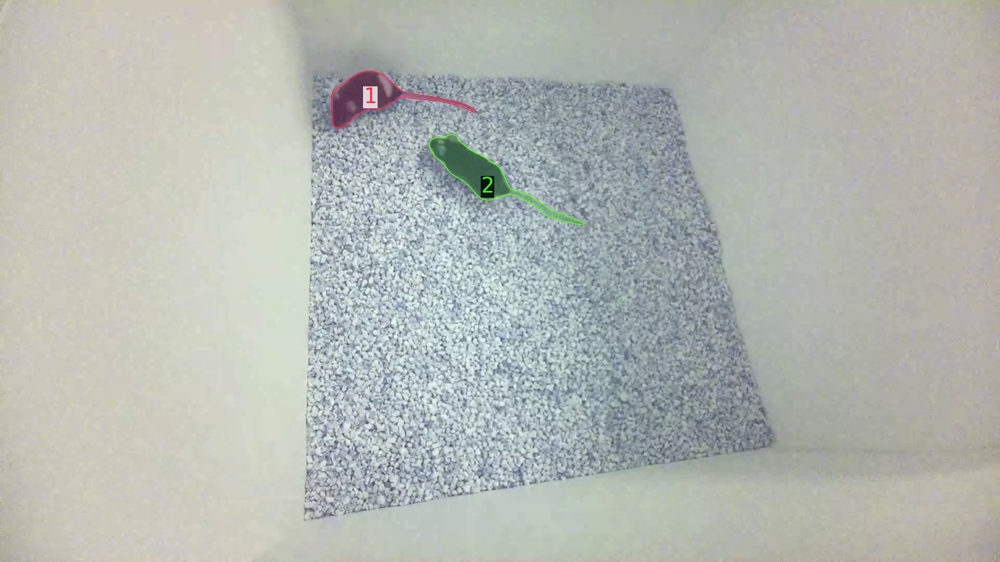

In [10]:
# prepare input args and run single image inference
image = "/home/adam/.sam3_zero_projects/553344c8-social-full-video/videos/05cfafae/frames/000789.jpg"
prompt = "the two mice with dark or shaved backs"
image = os.path.abspath(image)
send_generate_request = partial(send_generate_request_orig, server_url=LLM_SERVER_URL, model=llm_config["model"], api_key=llm_config["api_key"])
call_sam_service = partial(call_sam_service_orig, sam3_processor=processor)
output_image_path = run_single_image_inference(
    image, prompt, llm_config, send_generate_request, call_sam_service,
    debug=True, output_dir="agent_output"
)

# display output
if output_image_path is not None:
    display(Image(filename=output_image_path))

------------------------------ Starting SAM 3 Agent Session... ------------------------------ 
> Text prompt: the dark mouse
> Image path: /home/adam/.sam3_zero_projects/553344c8-social-full-video/videos/05cfafae/frames/032990.jpg



------------------------------ Round 1------------------------------



image_path /home/adam/.sam3_zero_projects/553344c8-social-full-video/videos/05cfafae/frames/032990.jpg
🔍 Calling model Qwen/Qwen3-VL-2B-Thinking-FP8...

>>> MLLM Response [start]
Okay, let me try to figure this out. The user provided an image with two mice on a bed of small white and blue grains, and the query is "the dark mouse".

First, I need to analyze the image. The image shows two mice, one is black with a white spot, and the other is dark but maybe black. The user is asking for "the dark mouse", so I need to find which one is darker.

Looking at the two mice: the one on the left has a black body with a white patch, and the one on the right is entirely dark. Wait, maybe the right

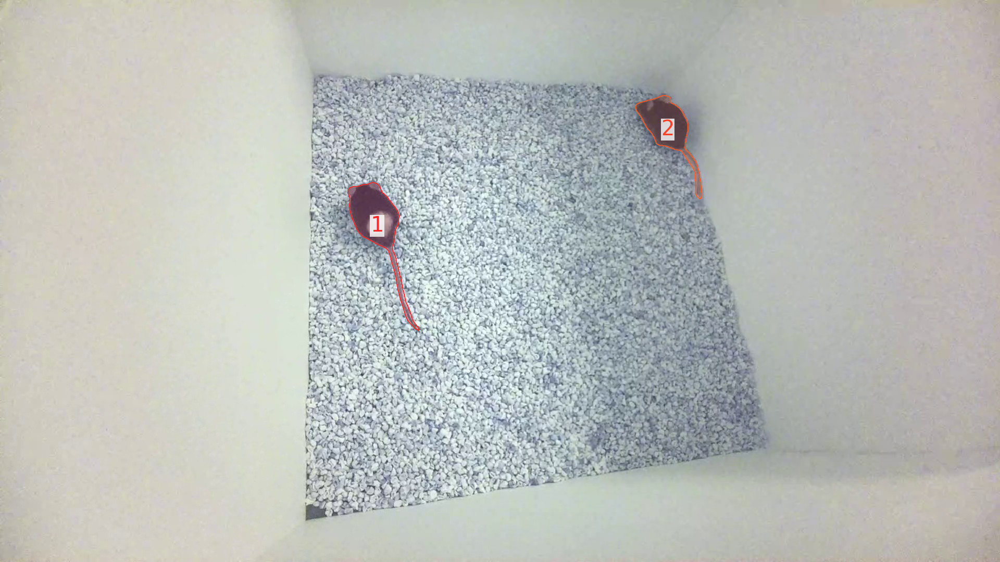

In [14]:
# prepare input args and run single image inference
image = "/home/adam/.sam3_zero_projects/553344c8-social-full-video/videos/05cfafae/frames/032990.jpg"
prompt = "the dark mouse"
image = os.path.abspath(image)
send_generate_request = partial(send_generate_request_orig, server_url=LLM_SERVER_URL, model=llm_config["model"], api_key=llm_config["api_key"])
call_sam_service = partial(call_sam_service_orig, sam3_processor=processor)
output_image_path = run_single_image_inference(
    image, prompt, llm_config, send_generate_request, call_sam_service,
    debug=True, output_dir="agent_output"
)

# display output
if output_image_path is not None:
    display(Image(filename=output_image_path))

------------------------------ Starting SAM 3 Agent Session... ------------------------------ 
> Text prompt: the two overlapping dark mice appearing as a blob
> Image path: /home/adam/.sam3_zero_projects/553344c8-social-full-video/videos/05cfafae/frames/041087.jpg



------------------------------ Round 1------------------------------



image_path /home/adam/.sam3_zero_projects/553344c8-social-full-video/videos/05cfafae/frames/041087.jpg
🔍 Calling model Qwen/Qwen3-VL-2B-Thinking-FP8...

>>> MLLM Response [start]
We are given a raw input image and an initial user input query: "the two overlapping dark mice appearing as a blob"

Analysis of the raw input image:
- The image shows a white container (or tray) with a large amount of small, light blue-gray gravel (or stones).
- In the lower right corner of the gravel, there is a single dark mouse (dark blue or black) with visible spots and a long tail. However, note that the description says "two overlapping dark mice", but we only see one 

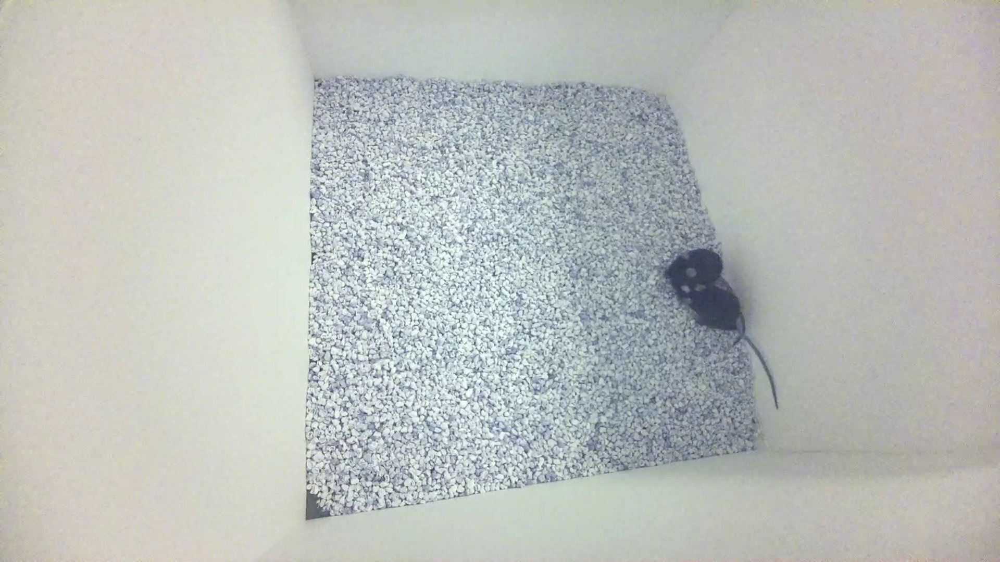

In [18]:
image = "/home/adam/.sam3_zero_projects/553344c8-social-full-video/videos/05cfafae/frames/041087.jpg"
prompt = "the two overlapping dark mice appearing as a blob"
image = os.path.abspath(image)
send_generate_request = partial(send_generate_request_orig, server_url=LLM_SERVER_URL, model=llm_config["model"], api_key=llm_config["api_key"])
call_sam_service = partial(call_sam_service_orig, sam3_processor=processor)
output_image_path = run_single_image_inference(
    image, prompt, llm_config, send_generate_request, call_sam_service,
    debug=True, output_dir="agent_output"
)

# display output
if output_image_path is not None:
    display(Image(filename=output_image_path))